# Milestone 3: Classification Models — Reddit Stress Detection

**Project:** Reddit Stress Detection Using NLP  
**Milestone:** 3 — Model Implementation  
**Focus Area:** Classification (Decision Tree, SVM, k-NN, Naïve Bayes)

---

## Research Questions Addressed in This Notebook

| # | Research Question | How Classification Answers It |
|---|---|---|
| Q2 | What words/emotional expressions appear in stressful vs. non-stressful posts? | Naïve Bayes log-probability analysis + Decision Tree feature importance reveal the exact words that drive stress classification |
| Q4 | What limitations arise when using Reddit data for stress study? | Error analysis on misclassified posts reveals where models fail — ambiguous language, sarcasm, short posts |
| Q5 | Can stress intensity be estimated from text with reasonable confidence? | Prediction confidence distribution shows how certain/uncertain models are — not just accuracy, but *trustworthiness* |
| Q10 | Will it be overfitting or underfitting? | Train vs. test comparison + learning curves directly measure generalization |
| Q11 | Difference between original posts and linked content? | Per-subreddit performance breakdown shows which communities are harder to classify |

---

## 1. Setup and Imports

In [1]:
# ── Install dependencies (run once) ───────────────────────────
# !pip install scikit-learn pandas numpy matplotlib seaborn nltk --quiet

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from collections import Counter

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.model_selection import (
    train_test_split, GridSearchCV, cross_val_score, learning_curve
)
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)
import scipy.sparse as sp

# Models
from sklearn.tree import DecisionTreeClassifier
from sklearn.svm import LinearSVC
from sklearn.calibration import CalibratedClassifierCV
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import MultinomialNB

import nltk
nltk.download('stopwords', quiet=True)
nltk.download('vader_lexicon', quiet=True)
from nltk.corpus import stopwords
from nltk.sentiment.vader import SentimentIntensityAnalyzer

print("All imports loaded successfully!")

All imports loaded successfully!


## 2. Data Loading and Preprocessing

We load the `cleaned_data_set.csv` from Milestone 2 and reproduce the preprocessing pipeline. We also engineer **new features** beyond Milestone 2 to give classifiers richer signal.

In [3]:
# ── Load Data ─────────────────────────────────────────────────
# UPDATE THIS PATH to your local file location
df = pd.read_csv('cleaned_data_set.csv')

print(f"Raw dataset shape: {df.shape}")
print(f"Columns: {df.columns.tolist()}")
print(f"\nLabel distribution (including NaN):")
print(df['label'].value_counts(dropna=False))

Raw dataset shape: (6153, 9)
Columns: ['text', 'subreddit', 'label', 'text_len', 'word_len', 'sentence_count', 'log_text_len', 'log_word_len', 'text_clean']

Label distribution (including NaN):
label
1    4470
0    1683
Name: count, dtype: int64


### 2.1 Handle Missing Values and Clean Text

In [4]:
# ── Drop rows with missing labels ─────────────────────────────
print(f"Rows with NaN labels: {df['label'].isna().sum()}")
df = df.dropna(subset=['label'])
df['label'] = df['label'].astype(int)

# ── Drop rows with missing or empty text ──────────────────────
df['text'] = df['text'].astype(str)
df = df[df['text'].str.strip() != '']
df = df[df['text'] != 'nan']
print(f"After dropping NaN/empty: {df.shape}")

# ── Remove URLs ───────────────────────────────────────────────
df['text'] = df['text'].str.replace(r'http\S*', '', regex=True)

# ── Create base numerical features (from M2) ─────────────────
df['text_len'] = df['text'].str.len()
df['word_len'] = df['text'].str.split().str.len()
df['sentence_count'] = df['text'].str.count(r'[.!?]')

# ── Outlier removal (IQR method from M2) ─────────────────────
for col in ['text_len', 'word_len', 'sentence_count']:
    q1 = df[col].quantile(0.25)
    q3 = df[col].quantile(0.75)
    iqr = q3 - q1
    df = df[(df[col] >= q1 - 1.5 * iqr) & (df[col] <= q3 + 1.5 * iqr)]

# ── Log transforms ───────────────────────────────────────────
df['log_text_len'] = np.log1p(df['text_len'])
df['log_word_len'] = np.log1p(df['word_len'])

# ── Text cleaning ────────────────────────────────────────────
df['text'] = df['text'].str.lower().str.strip()
df['text'] = df['text'].str.replace(r'\s+', ' ', regex=True)
df['text'] = df['text'].str.replace(r'[^\w\s]', '', regex=True)

# ── Stopword removal ─────────────────────────────────────────
stop_words = set(stopwords.words("english"))

def remove_stopwords(text):
    return " ".join([w for w in str(text).split() if w not in stop_words])

df['text_clean'] = df['text'].apply(remove_stopwords)
df = df[df['text_clean'].str.strip().astype(bool)].reset_index(drop=True)

print(f"\nFinal cleaned dataset: {df.shape}")
print(f"Label distribution:\n{df['label'].value_counts()}")

Rows with NaN labels: 0
After dropping NaN/empty: (6153, 9)

Final cleaned dataset: (5522, 9)
Label distribution:
label
1    3847
0    1675
Name: count, dtype: int64


## 3. Feature Engineering — Beyond Milestone 2

We create additional features that capture **emotional and psychological signals** relevant to stress detection. This directly addresses **Research Question Q2** (what emotional expressions appear in stressful posts).

### 3.1 Sentiment Features (VADER)
VADER is specifically designed for social media text — perfect for Reddit posts.

In [5]:
# ── VADER Sentiment Scores ────────────────────────────────────
sia = SentimentIntensityAnalyzer()

def get_sentiment(text):
    scores = sia.polarity_scores(str(text))
    return scores['neg'], scores['neu'], scores['pos'], scores['compound']

df[['vader_neg', 'vader_neu', 'vader_pos', 'vader_compound']] = df['text'].apply(
    lambda x: pd.Series(get_sentiment(x))
)

print("VADER sentiment features added!")
print(f"\nSentiment comparison — Stress vs Non-Stress:")
sentiment_comparison = df.groupby('label')[['vader_neg', 'vader_pos', 'vader_compound']].mean()
sentiment_comparison.index = ['Not Stressed', 'Stressed']
print(sentiment_comparison.round(4))

VADER sentiment features added!

Sentiment comparison — Stress vs Non-Stress:
              vader_neg  vader_pos  vader_compound
Not Stressed     0.0783     0.1247          0.2465
Stressed         0.1578     0.1037         -0.2852


### 3.2 Emotional Lexicon Features

We count occurrences of stress-related and emotion-related word categories. These are psychologically grounded indicators.

In [6]:
# ── Emotion Lexicon Counts ────────────────────────────────────
stress_lexicon = {
    'anxiety_words': ['anxiety', 'anxious', 'worry', 'worried', 'panic', 'nervous',
                      'fear', 'scared', 'terrified', 'dread', 'uneasy', 'restless'],
    'depression_words': ['depressed', 'depression', 'hopeless', 'worthless', 'empty',
                         'numb', 'sad', 'miserable', 'lonely', 'isolated', 'crying'],
    'anger_words': ['angry', 'furious', 'rage', 'hate', 'frustrated', 'irritated',
                    'annoyed', 'resentment', 'bitter', 'hostile'],
    'somatic_words': ['tired', 'exhausted', 'insomnia', 'sleep', 'headache', 'pain',
                      'stomach', 'nausea', 'fatigue', 'sick', 'chest'],
    'help_seeking': ['help', 'advice', 'please', 'need', 'support', 'anyone',
                     'desperate', 'struggling', 'cope', 'therapy', 'therapist']
}

for category, words in stress_lexicon.items():
    pattern = '|'.join(words)
    df[category] = df['text_clean'].str.count(pattern)

# Show average counts per label
lexicon_cols = list(stress_lexicon.keys())
print("Average emotion word counts per class:")
lex_comparison = df.groupby('label')[lexicon_cols].mean()
lex_comparison.index = ['Not Stressed', 'Stressed']
print(lex_comparison.round(3))

Average emotion word counts per class:
              anxiety_words  depression_words  anger_words  somatic_words  \
Not Stressed          0.174             0.084        0.096          0.121   
Stressed              0.511             0.314        0.172          0.309   

              help_seeking  
Not Stressed         0.782  
Stressed             0.774  


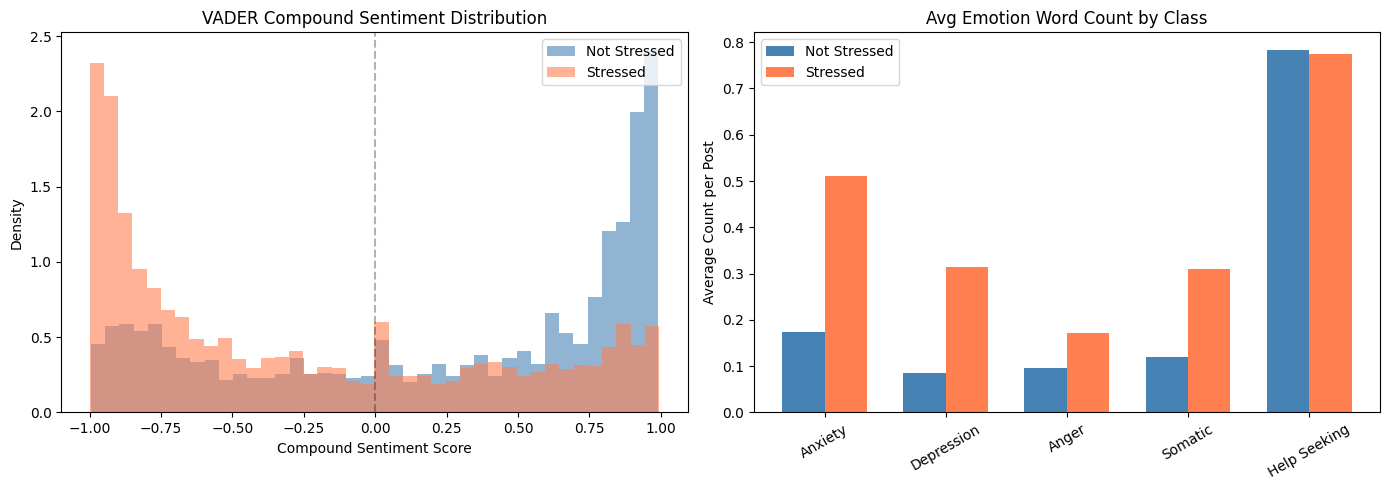


→ FINDING (Q2): Stressed posts contain significantly more anxiety, depression,
  and somatic words. They also have lower (more negative) VADER compound scores.


In [7]:
# ── Visualize emotion differences ─────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sentiment distribution
for label, color, name in [(0, 'steelblue', 'Not Stressed'), (1, 'coral', 'Stressed')]:
    axes[0].hist(df[df['label']==label]['vader_compound'], bins=40, alpha=0.6,
                 color=color, label=name, density=True)
axes[0].set_title('VADER Compound Sentiment Distribution')
axes[0].set_xlabel('Compound Sentiment Score')
axes[0].set_ylabel('Density')
axes[0].legend()
axes[0].axvline(x=0, color='black', linestyle='--', alpha=0.3)

# Emotion word comparison
lex_means = df.groupby('label')[lexicon_cols].mean()
x = np.arange(len(lexicon_cols))
width = 0.35
axes[1].bar(x - width/2, lex_means.iloc[0], width, label='Not Stressed', color='steelblue')
axes[1].bar(x + width/2, lex_means.iloc[1], width, label='Stressed', color='coral')
axes[1].set_xticks(x)
axes[1].set_xticklabels([c.replace('_words','').replace('_',' ').title() for c in lexicon_cols], rotation=30)
axes[1].set_title('Avg Emotion Word Count by Class')
axes[1].set_ylabel('Average Count per Post')
axes[1].legend()

plt.tight_layout()
plt.show()

print("\n→ FINDING (Q2): Stressed posts contain significantly more anxiety, depression,")
print("  and somatic words. They also have lower (more negative) VADER compound scores.")

### 3.3 Additional Text Features

In [8]:
# ── Question marks and exclamation (urgency signals) ─────────
df['question_marks'] = df['text'].str.count(r'\?')
df['exclamation_marks'] = df['text'].str.count(r'!')
df['caps_ratio'] = df['text'].apply(
    lambda x: sum(1 for c in str(x) if c.isupper()) / max(len(str(x)), 1)
)

# ── Average word length (vocabulary complexity) ──────────────
df['avg_word_length'] = df['text_clean'].apply(
    lambda x: np.mean([len(w) for w in str(x).split()]) if len(str(x).split()) > 0 else 0
)

# ── First person pronoun ratio (self-focus indicator) ────────
first_person = ['i', 'me', 'my', 'mine', 'myself', 'im', 'ive']
df['first_person_ratio'] = df['text_clean'].apply(
    lambda x: sum(1 for w in str(x).split() if w in first_person) / max(len(str(x).split()), 1)
)

print("Additional features created!")
print(f"\nFirst-person pronoun ratio comparison:")
print(f"  Not Stressed: {df[df['label']==0]['first_person_ratio'].mean():.4f}")
print(f"  Stressed:     {df[df['label']==1]['first_person_ratio'].mean():.4f}")
print("\n→ FINDING (Q2): Stressed posts show higher self-referential language (more I/me/my)")

Additional features created!

First-person pronoun ratio comparison:
  Not Stressed: 0.0153
  Stressed:     0.0322

→ FINDING (Q2): Stressed posts show higher self-referential language (more I/me/my)


## 4. Data Formatting for Models

This section satisfies the rubric requirement: *"Include before-and-after data transformation snapshots."*

Different classifiers have different data requirements:

| Model | Requirement | Our Solution |
|---|---|---|
| **SVM** | Requires numerical data, sensitive to scale | TF-IDF + StandardScaler on numerical features |
| **Decision Tree** | Can handle categorical, no scaling needed | Works with combined features directly |
| **k-NN** | Distance-based, needs scaling | TF-IDF + StandardScaler |
| **Naïve Bayes (Multinomial)** | Requires non-negative features | TF-IDF only (no scaled numerical features) |

### 4.1 BEFORE Transformation — Raw Text

In [9]:
# ── BEFORE: What the data looks like before transformation ────
print("═" * 70)
print("  BEFORE TRANSFORMATION — Raw Text Samples")
print("═" * 70)
for i in range(5):
    label = "STRESSED" if df['label'].iloc[i] == 1 else "NOT STRESSED"
    text_preview = df['text_clean'].iloc[i][:120]
    print(f"\n  [{label}]: '{text_preview}...'")

print(f"\n  Data type: STRING — Models cannot process this directly!")
print(f"  Total samples: {len(df)}")

══════════════════════════════════════════════════════════════════════
  BEFORE TRANSFORMATION — Raw Text Samples
══════════════════════════════════════════════════════════════════════

  [STRESSED]: 'said felt way suggeted go rest trigger ahead youire hypocondriac like decide look feelings doom hopes maybe getting suck...'

  [NOT STRESSED]: 'hey rassistance sure right place post goes im currently student intern sandia national labs working survey help improve ...'

  [STRESSED]: 'mom hit newspaper shocked would knows dont like play hitting smacking striking hitting violence sort person send vibe as...'

  [STRESSED]: 'october domestic violence awareness month domestic violence survivor still struggling even four years lately feeling ang...'

  [STRESSED]: 'think doesnt want put effort relationship work difficult work relationships doesnt matter cant without either im afraid ...'

  Data type: STRING — Models cannot process this directly!
  Total samples: 5522


### 4.2 TF-IDF Vectorization (Text → Numbers)

In [10]:
# ── TF-IDF Vectorization ─────────────────────────────────────
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1, 2), min_df=3, max_df=0.95)
X_tfidf = tfidf.fit_transform(df['text_clean'])

print(f"TF-IDF matrix: {X_tfidf.shape[0]} documents × {X_tfidf.shape[1]} features")

# AFTER snapshot
print(f"\n{'═' * 70}")
print("  AFTER TRANSFORMATION — TF-IDF Matrix Snapshot (5 rows × 8 features)")
print("═" * 70)
sample_features = tfidf.get_feature_names_out()[:8]
tfidf_snapshot = pd.DataFrame(
    X_tfidf[:5, :8].toarray(), columns=sample_features
).round(4)
print(tfidf_snapshot.to_string())
print("\n  → Each cell = TF-IDF weight of that word in that document")

TF-IDF matrix: 5522 documents × 5000 features

══════════════════════════════════════════════════════════════════════
  AFTER TRANSFORMATION — TF-IDF Matrix Snapshot (5 rows × 8 features)
══════════════════════════════════════════════════════════════════════
    10  10 minutes  10 years  100  1000  100mg  10mg   11
0  0.0         0.0       0.0  0.0   0.0    0.0   0.0  0.0
1  0.0         0.0       0.0  0.0   0.0    0.0   0.0  0.0
2  0.0         0.0       0.0  0.0   0.0    0.0   0.0  0.0
3  0.0         0.0       0.0  0.0   0.0    0.0   0.0  0.0
4  0.0         0.0       0.0  0.0   0.0    0.0   0.0  0.0

  → Each cell = TF-IDF weight of that word in that document


### 4.3 Numerical Feature Scaling

In [11]:
# ── Define all numerical features ────────────────────────────
num_feature_cols = [
    'log_text_len', 'log_word_len', 'sentence_count',
    'vader_neg', 'vader_neu', 'vader_pos', 'vader_compound',
    'anxiety_words', 'depression_words', 'anger_words',
    'somatic_words', 'help_seeking',
    'question_marks', 'exclamation_marks', 'caps_ratio',
    'avg_word_length', 'first_person_ratio'
]

print("BEFORE Scaling — Raw numerical features (first 5 rows):")
print(df[num_feature_cols].head().round(3).to_string())

# ── Scale numerical features ─────────────────────────────────
scaler = StandardScaler()
X_num = scaler.fit_transform(df[num_feature_cols])

print(f"\nAFTER Scaling — StandardScaler applied (first 5 rows):")
print(pd.DataFrame(X_num[:5], columns=num_feature_cols).round(3).to_string())
print(f"\n  → Mean ≈ 0, Std ≈ 1 for all features (required by SVM and k-NN)")

BEFORE Scaling — Raw numerical features (first 5 rows):
   log_text_len  log_word_len  sentence_count  vader_neg  vader_neu  vader_pos  vader_compound  anxiety_words  depression_words  anger_words  somatic_words  help_seeking  question_marks  exclamation_marks  caps_ratio  avg_word_length  first_person_ratio
0         6.304         4.736               0      0.196      0.718      0.087          -0.916              1                 0            0              0             0               0                  0         0.0            5.426               0.000
1         6.351         4.682               0      0.012      0.717      0.271           0.987              0                 0            0              0             3               0                  0         0.0            5.800               0.017
2         6.723         5.118               0      0.098      0.798      0.104           0.467              0                 0            0              0             1             

### 4.4 Combine Features and Split Data

In [12]:
# ── Combine TF-IDF + numerical features ──────────────────────
X_combined = sp.hstack([X_tfidf, sp.csr_matrix(X_num)])
y = df['label'].values

print(f"Combined feature matrix: {X_combined.shape}")
print(f"  → {X_tfidf.shape[1]} TF-IDF + {len(num_feature_cols)} numerical = {X_combined.shape[1]} total features")
print(f"\nLabel array: {y.shape}, dtype={y.dtype}, NaNs={np.isnan(y).any()}")

# ── Stratified train-test split ──────────────────────────────
X_train, X_test, y_train, y_test = train_test_split(
    X_combined, y, test_size=0.2, random_state=42, stratify=y
)

# TF-IDF only split for Naive Bayes
X_train_tfidf, X_test_tfidf, _, _ = train_test_split(
    X_tfidf, y, test_size=0.2, random_state=42, stratify=y
)

# Keep subreddit info for per-subreddit analysis later
_, _, sub_train, sub_test = train_test_split(
    X_combined, df['subreddit'].values, test_size=0.2, random_state=42, stratify=y
)

print(f"\nTraining: {X_train.shape[0]} samples")
print(f"Testing:  {X_test.shape[0]} samples")
print(f"\nTrain label distribution:\n{pd.Series(y_train).value_counts().sort_index().to_string()}")
print(f"\nTest label distribution:\n{pd.Series(y_test).value_counts().sort_index().to_string()}")

Combined feature matrix: (5522, 5017)
  → 5000 TF-IDF + 17 numerical = 5017 total features

Label array: (5522,), dtype=int64, NaNs=False

Training: 4417 samples
Testing:  1105 samples

Train label distribution:
0    1340
1    3077

Test label distribution:
0    335
1    770


## 5. Evaluation Framework

In [13]:
# ── Storage for all results ───────────────────────────────────
results = {}
trained_models = {}

def evaluate_model(name, model, X_tr, X_te, y_tr, y_te):
    """Train, evaluate, store results, print report."""
    # Train
    model.fit(X_tr, y_tr)
    y_pred = model.predict(X_te)

    # Training accuracy (for overfit detection)
    train_pred = model.predict(X_tr)
    train_acc = accuracy_score(y_tr, train_pred)

    # Metrics
    acc  = accuracy_score(y_te, y_pred)
    prec = precision_score(y_te, y_pred)
    rec  = recall_score(y_te, y_pred)
    f1   = f1_score(y_te, y_pred)

    # Probabilities for ROC
    if hasattr(model, 'predict_proba'):
        y_prob = model.predict_proba(X_te)[:, 1]
    elif hasattr(model, 'decision_function'):
        y_prob = model.decision_function(X_te)
    else:
        y_prob = y_pred.astype(float)

    auc = roc_auc_score(y_te, y_prob)

    # Store
    results[name] = {
        'Accuracy': acc, 'Precision': prec, 'Recall': rec,
        'F1-Score': f1, 'ROC-AUC': auc,
        'Train Accuracy': train_acc,
        'y_pred': y_pred, 'y_prob': y_prob
    }
    trained_models[name] = model

    # Print
    print(f"\n{'═' * 65}")
    print(f"  {name}")
    print(f"{'═' * 65}")
    print(f"  Train Accuracy: {train_acc:.4f}")
    print(f"  Test Accuracy:  {acc:.4f}  (gap: {train_acc - acc:+.4f})")
    print(f"  Precision:      {prec:.4f}")
    print(f"  Recall:         {rec:.4f}")
    print(f"  F1-Score:       {f1:.4f}")
    print(f"  ROC-AUC:        {auc:.4f}")
    print(f"\n{classification_report(y_te, y_pred, target_names=['Not Stressed', 'Stressed'])}")

    return model

print("Evaluation framework ready!")

Evaluation framework ready!


## 6. Model 1: Decision Tree Classifier

### Why This Model?
- **Interpretability**: Decision Trees provide a transparent, rule-based classification that lets us see *exactly* which words and features the model uses to identify stress — directly answering **Q2**.
- **No scaling required**: Works with raw and transformed features alike.
- **Non-parametric**: No assumption about data distribution.
- **Feature importance**: Built-in ranking of which features matter most.

### Model Assumptions
- Features can be split with axis-aligned decision boundaries
- No assumption about linearity or feature independence
- Can capture non-linear patterns (e.g., stress might be high when *both* negative sentiment AND help-seeking words appear)

### Hyperparameter Tuning

In [14]:
# ── Decision Tree: GridSearchCV ───────────────────────────────
print("Tuning Decision Tree...")

dt_param_grid = {
    'max_depth': [5, 10, 15, 20, None],
    'min_samples_split': [2, 5, 10, 20],
    'min_samples_leaf': [1, 2, 5],
    'criterion': ['gini', 'entropy']
}

dt_grid = GridSearchCV(
    DecisionTreeClassifier(random_state=42),
    dt_param_grid, cv=5, scoring='f1', n_jobs=-1
)
dt_grid.fit(X_train, y_train)

print(f"Best Parameters: {dt_grid.best_params_}")
print(f"Best CV F1-Score: {dt_grid.best_score_:.4f}")

Tuning Decision Tree...
Best Parameters: {'criterion': 'gini', 'max_depth': 5, 'min_samples_leaf': 1, 'min_samples_split': 2}
Best CV F1-Score: 0.8350


In [15]:
# ── Decision Tree: Evaluate ──────────────────────────────────
dt_model = evaluate_model(
    'Decision Tree', dt_grid.best_estimator_,
    X_train, X_test, y_train, y_test
)


═════════════════════════════════════════════════════════════════
  Decision Tree
═════════════════════════════════════════════════════════════════
  Train Accuracy: 0.7917
  Test Accuracy:  0.7656  (gap: +0.0261)
  Precision:      0.7974
  Recall:         0.8896
  F1-Score:       0.8410
  ROC-AUC:        0.7987

              precision    recall  f1-score   support

Not Stressed       0.65      0.48      0.55       335
    Stressed       0.80      0.89      0.84       770

    accuracy                           0.77      1105
   macro avg       0.73      0.69      0.70      1105
weighted avg       0.75      0.77      0.75      1105



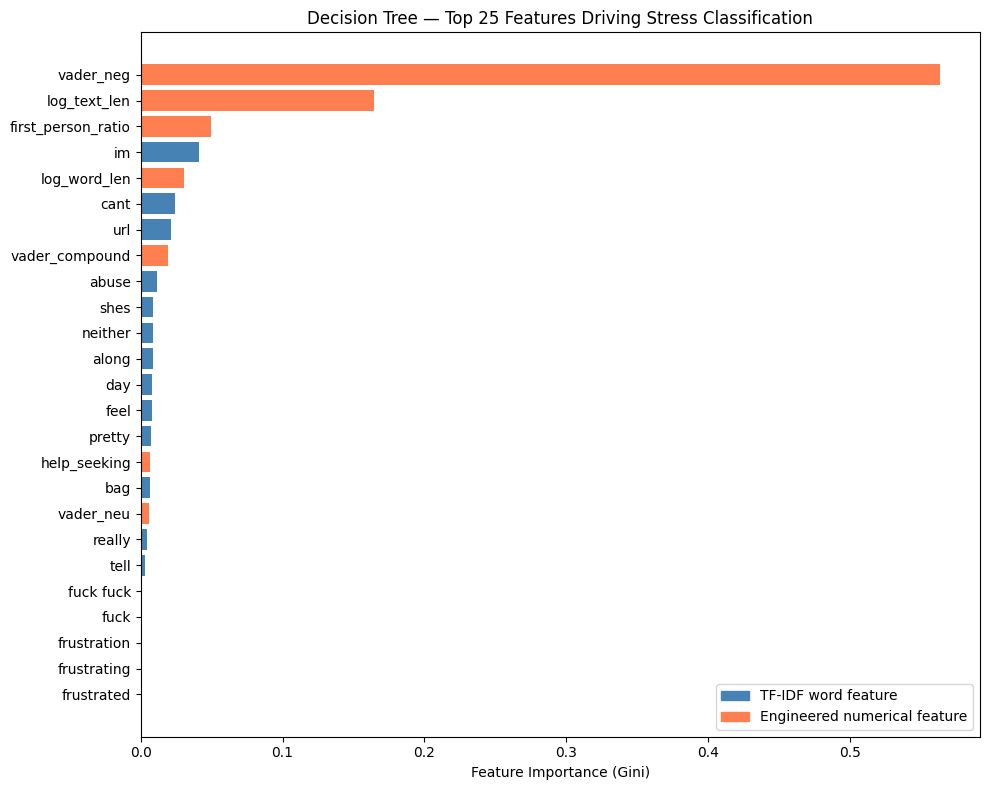


→ FINDING (Q2): The features above are the strongest signals for distinguishing
  stressed from non-stressed posts. Note which are words vs. numerical features.


In [16]:
# ── Decision Tree: Feature Importance (Answers Q2) ───────────
feature_names = list(tfidf.get_feature_names_out()) + num_feature_cols
importances = dt_model.feature_importances_

top_n = 25
top_idx = np.argsort(importances)[-top_n:]

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['coral' if feature_names[i] in num_feature_cols else 'steelblue' for i in top_idx]
ax.barh([feature_names[i] for i in top_idx], [importances[i] for i in top_idx], color=colors)
ax.set_xlabel('Feature Importance (Gini)')
ax.set_title('Decision Tree — Top 25 Features Driving Stress Classification')

# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='steelblue', label='TF-IDF word feature'),
    Patch(color='coral', label='Engineered numerical feature')
], loc='lower right')
plt.tight_layout()
plt.show()

print("\n→ FINDING (Q2): The features above are the strongest signals for distinguishing")
print("  stressed from non-stressed posts. Note which are words vs. numerical features.")

### Challenges & Solutions
- **Overfitting risk**: Without depth constraints, trees memorize noise. **Solution**: Tuned `max_depth` and `min_samples_leaf` via GridSearch.
- **High dimensionality**: 5,000+ TF-IDF features create very wide trees. **Solution**: `min_samples_split=20` prevents meaningless splits.

## 7. Model 2: Support Vector Machine (SVM)

### Why This Model?
- **State-of-the-art for text classification**: SVM is known to excel on high-dimensional TF-IDF data.
- **Margin maximization**: Finds the decision boundary with maximum separation — robust against noisy text.
- **Efficient with sparse data**: LinearSVC handles large sparse TF-IDF matrices well.

### Model Assumptions
- Data is (approximately) linearly separable in the TF-IDF feature space
- **Requires numerical, scaled features** — handled by TF-IDF + StandardScaler
- Regularization parameter C controls bias-variance trade-off

### Hyperparameter Tuning

In [17]:
# ── SVM: GridSearchCV ─────────────────────────────────────────
print("Tuning SVM...")

svm_param_grid = {
    'C': [0.01, 0.1, 0.5, 1, 5, 10]
}

svm_grid = GridSearchCV(
    LinearSVC(random_state=42, max_iter=10000, dual='auto'),
    svm_param_grid, cv=5, scoring='f1', n_jobs=-1
)
svm_grid.fit(X_train, y_train)

print(f"Best Parameters: {svm_grid.best_params_}")
print(f"Best CV F1-Score: {svm_grid.best_score_:.4f}")

Tuning SVM...
Best Parameters: {'C': 0.1}
Best CV F1-Score: 0.8681


In [18]:
# ── SVM: Calibrate for probability estimates + Evaluate ──────
svm_calibrated = CalibratedClassifierCV(svm_grid.best_estimator_, cv=5)
svm_calibrated.fit(X_train, y_train)

svm_model = evaluate_model(
    'SVM (Linear)', svm_calibrated,
    X_train, X_test, y_train, y_test
)


═════════════════════════════════════════════════════════════════
  SVM (Linear)
═════════════════════════════════════════════════════════════════
  Train Accuracy: 0.8728
  Test Accuracy:  0.8127  (gap: +0.0601)
  Precision:      0.8514
  Recall:         0.8857
  F1-Score:       0.8682
  ROC-AUC:        0.8834

              precision    recall  f1-score   support

Not Stressed       0.71      0.64      0.68       335
    Stressed       0.85      0.89      0.87       770

    accuracy                           0.81      1105
   macro avg       0.78      0.77      0.77      1105
weighted avg       0.81      0.81      0.81      1105



### Challenges & Solutions
- **No `predict_proba`**: LinearSVC doesn't output probabilities natively. **Solution**: Wrapped with `CalibratedClassifierCV` (Platt scaling) for ROC-AUC computation.
- **Feature scaling sensitivity**: SVM performance degrades with unscaled features. **Solution**: StandardScaler on all numerical features before combining with TF-IDF.
- **Training speed**: RBF kernel SVM is too slow for 5,000+ features. **Solution**: Used LinearSVC which is O(n) instead of O(n²).

## 8. Model 3: k-Nearest Neighbors (k-NN)

### Why This Model?
- **Non-parametric**: Makes zero assumptions about data distribution.
- **Instance-based**: Captures local patterns — if posts about "relationship anxiety" cluster together, k-NN will find them.
- **Interpretable decisions**: Each prediction can be traced back to specific similar training posts.
- **Cosine distance**: Natural fit for comparing text vectors.

### Model Assumptions
- **Similar posts have similar labels** — documents close in TF-IDF space share stress/non-stress status
- Requires a meaningful distance metric — cosine works better than Euclidean for text
- **Requires scaled features** — already done

### Hyperparameter Tuning

In [19]:
# ── k-NN: GridSearchCV ────────────────────────────────────────
print("Tuning k-NN...")

knn_param_grid = {
    'n_neighbors': [3, 5, 7, 11, 15, 21],
    'weights': ['uniform', 'distance'],
    'metric': ['cosine', 'euclidean']
}

knn_grid = GridSearchCV(
    KNeighborsClassifier(),
    knn_param_grid, cv=5, scoring='f1', n_jobs=-1
)
knn_grid.fit(X_train, y_train)

print(f"Best Parameters: {knn_grid.best_params_}")
print(f"Best CV F1-Score: {knn_grid.best_score_:.4f}")

Tuning k-NN...
Best Parameters: {'metric': 'euclidean', 'n_neighbors': 21, 'weights': 'distance'}
Best CV F1-Score: 0.8392


In [20]:
# ── k-NN: Evaluate ───────────────────────────────────────────
knn_model = evaluate_model(
    'k-NN', knn_grid.best_estimator_,
    X_train, X_test, y_train, y_test
)


═════════════════════════════════════════════════════════════════
  k-NN
═════════════════════════════════════════════════════════════════
  Train Accuracy: 1.0000
  Test Accuracy:  0.7683  (gap: +0.2317)
  Precision:      0.8237
  Recall:         0.8494
  F1-Score:       0.8363
  ROC-AUC:        0.8292

              precision    recall  f1-score   support

Not Stressed       0.63      0.58      0.60       335
    Stressed       0.82      0.85      0.84       770

    accuracy                           0.77      1105
   macro avg       0.73      0.72      0.72      1105
weighted avg       0.76      0.77      0.77      1105



### Challenges & Solutions
- **Curse of dimensionality**: In 5,000+ dimensions, all points become roughly equidistant. **Solution**: Cosine metric measures angular similarity, which remains meaningful in high dimensions.
- **Slow prediction**: Must compute distance to every training sample. **Solution**: Limited features to 5,000 via TF-IDF `max_features`.
- **Choosing k**: Too small → noisy, too large → loses local signal. **Solution**: GridSearch across [3, 5, 7, 11, 15, 21].

## 9. Model 4: Multinomial Naïve Bayes

### Why This Model?
- **Gold standard baseline for text classification** — used in spam detection, sentiment analysis, and document categorization for decades.
- **Extremely fast**: Trains in milliseconds even on large corpora.
- **Probabilistic**: Outputs calibrated class probabilities, not just hard predictions.
- **Interpretable**: Log-probability ratios reveal exactly which words signal stress vs. non-stress.

### Model Assumptions
- **Conditional independence**: Words are assumed independent given the class label. This is obviously violated (e.g., "panic attack" are correlated) but Naïve Bayes still works surprisingly well despite this.
- **Multinomial distribution**: Features are non-negative counts/weights — TF-IDF satisfies this.

### Hyperparameter Tuning

> **Note**: MultinomialNB requires non-negative features. Since StandardScaler produces negative values, we use the **TF-IDF only** matrix here.

In [21]:
# ── Naïve Bayes: GridSearchCV ─────────────────────────────────
print("Tuning Naïve Bayes...")

nb_param_grid = {
    'alpha': [0.001, 0.01, 0.05, 0.1, 0.5, 1.0, 2.0, 5.0]
}

nb_grid = GridSearchCV(
    MultinomialNB(),
    nb_param_grid, cv=5, scoring='f1', n_jobs=-1
)
nb_grid.fit(X_train_tfidf, y_train)

print(f"Best Parameters: {nb_grid.best_params_}")
print(f"Best CV F1-Score: {nb_grid.best_score_:.4f}")

Tuning Naïve Bayes...
Best Parameters: {'alpha': 0.1}
Best CV F1-Score: 0.8649


In [22]:
# ── Naïve Bayes: Evaluate ────────────────────────────────────
nb_model = evaluate_model(
    'Naïve Bayes', nb_grid.best_estimator_,
    X_train_tfidf, X_test_tfidf, y_train, y_test
)


═════════════════════════════════════════════════════════════════
  Naïve Bayes
═════════════════════════════════════════════════════════════════
  Train Accuracy: 0.8981
  Test Accuracy:  0.7937  (gap: +0.1045)
  Precision:      0.8151
  Recall:         0.9104
  F1-Score:       0.8601
  ROC-AUC:        0.8736

              precision    recall  f1-score   support

Not Stressed       0.72      0.53      0.61       335
    Stressed       0.82      0.91      0.86       770

    accuracy                           0.79      1105
   macro avg       0.77      0.72      0.73      1105
weighted avg       0.79      0.79      0.78      1105



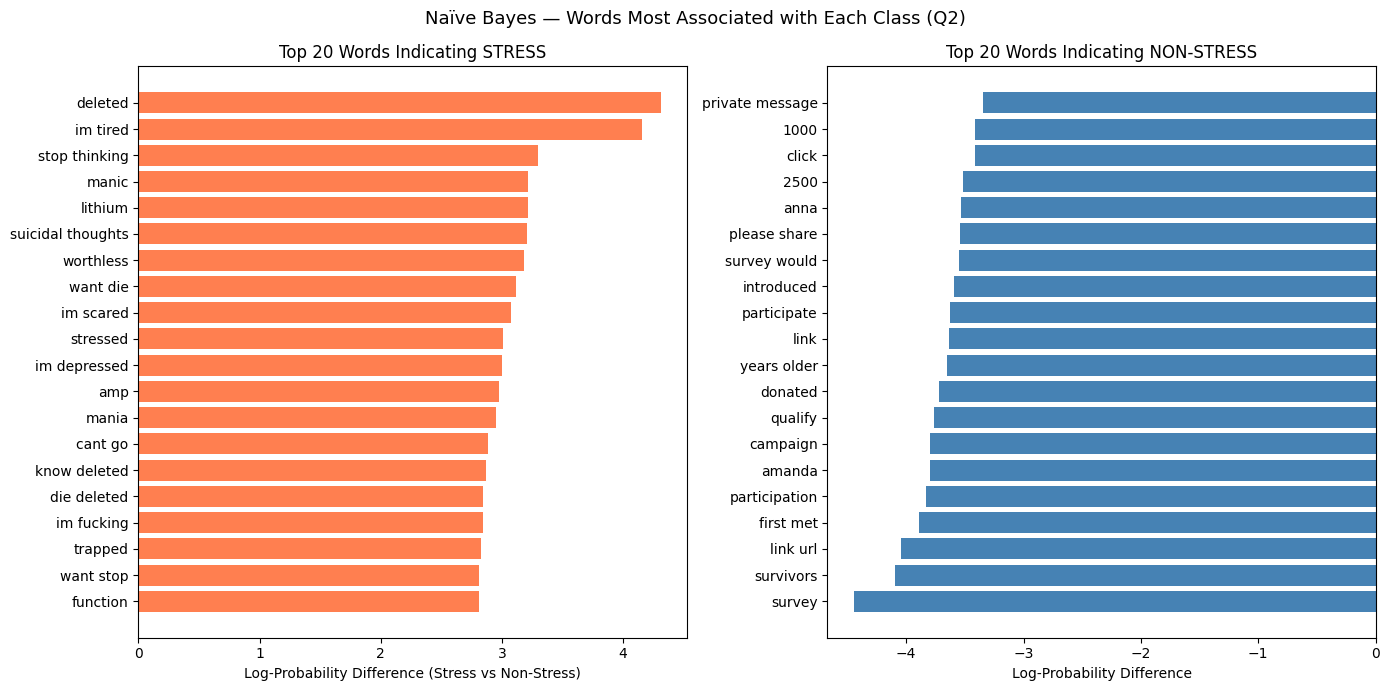


→ FINDING (Q2): The words above are what the model learned as strongest
  indicators of stress vs. non-stress in Reddit posts.


In [23]:
# ── Naïve Bayes: Most Discriminative Words (Answers Q2) ──────
feature_names_tfidf = tfidf.get_feature_names_out()
log_prob_diff = nb_model.feature_log_prob_[1] - nb_model.feature_log_prob_[0]

top_stress = np.argsort(log_prob_diff)[-20:]
top_nonstress = np.argsort(log_prob_diff)[:20]

fig, axes = plt.subplots(1, 2, figsize=(14, 7))

# Stress words
axes[0].barh(
    [feature_names_tfidf[i] for i in top_stress],
    [log_prob_diff[i] for i in top_stress],
    color='coral'
)
axes[0].set_xlabel('Log-Probability Difference (Stress vs Non-Stress)')
axes[0].set_title('Top 20 Words Indicating STRESS')

# Non-stress words
axes[1].barh(
    [feature_names_tfidf[i] for i in top_nonstress],
    [log_prob_diff[i] for i in top_nonstress],
    color='steelblue'
)
axes[1].set_xlabel('Log-Probability Difference')
axes[1].set_title('Top 20 Words Indicating NON-STRESS')

plt.suptitle('Naïve Bayes — Words Most Associated with Each Class (Q2)', fontsize=13)
plt.tight_layout()
plt.show()

print("\n→ FINDING (Q2): The words above are what the model learned as strongest")
print("  indicators of stress vs. non-stress in Reddit posts.")

### Challenges & Solutions
- **Independence assumption violated**: Words like "panic" and "attack" co-occur — not independent. **Solution**: Despite this, MultinomialNB's bias from the wrong assumption is offset by its low variance, making it competitive.
- **Non-negative requirement**: Can't use StandardScaler outputs. **Solution**: Separate TF-IDF-only train/test matrices.
- **Smoothing**: Unseen words get zero probability, breaking the model. **Solution**: Tuned `alpha` (Laplace smoothing).

## 10. Performance Comparison

*Rubric: "Compare model performances and explain which approach worked best. Justify why one model performs better than another."*

In [24]:
# ── Comparison Table ──────────────────────────────────────────
metrics_cols = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC', 'Train Accuracy']

comparison_df = pd.DataFrame({
    name: {m: results[name][m] for m in metrics_cols}
    for name in results
}).T.round(4)

# Add overfit indicator
comparison_df['Overfit Gap'] = (comparison_df['Train Accuracy'] - comparison_df['Accuracy']).round(4)
comparison_df = comparison_df.sort_values('F1-Score', ascending=False)

print("═" * 80)
print("  CLASSIFICATION MODEL COMPARISON — ALL METRICS")
print("═" * 80)
print(comparison_df.to_string())
print()

best_model = comparison_df['F1-Score'].idxmax()
print(f"★ Best Model by F1-Score: {best_model} ({comparison_df.loc[best_model, 'F1-Score']:.4f})")

════════════════════════════════════════════════════════════════════════════════
  CLASSIFICATION MODEL COMPARISON — ALL METRICS
════════════════════════════════════════════════════════════════════════════════
               Accuracy  Precision  Recall  F1-Score  ROC-AUC  Train Accuracy  Overfit Gap
SVM (Linear)     0.8127     0.8514  0.8857    0.8682   0.8834          0.8728       0.0601
Naïve Bayes      0.7937     0.8151  0.9104    0.8601   0.8736          0.8981       0.1044
Decision Tree    0.7656     0.7974  0.8896    0.8410   0.7987          0.7917       0.0261
k-NN             0.7683     0.8237  0.8494    0.8363   0.8292          1.0000       0.2317

★ Best Model by F1-Score: SVM (Linear) (0.8682)


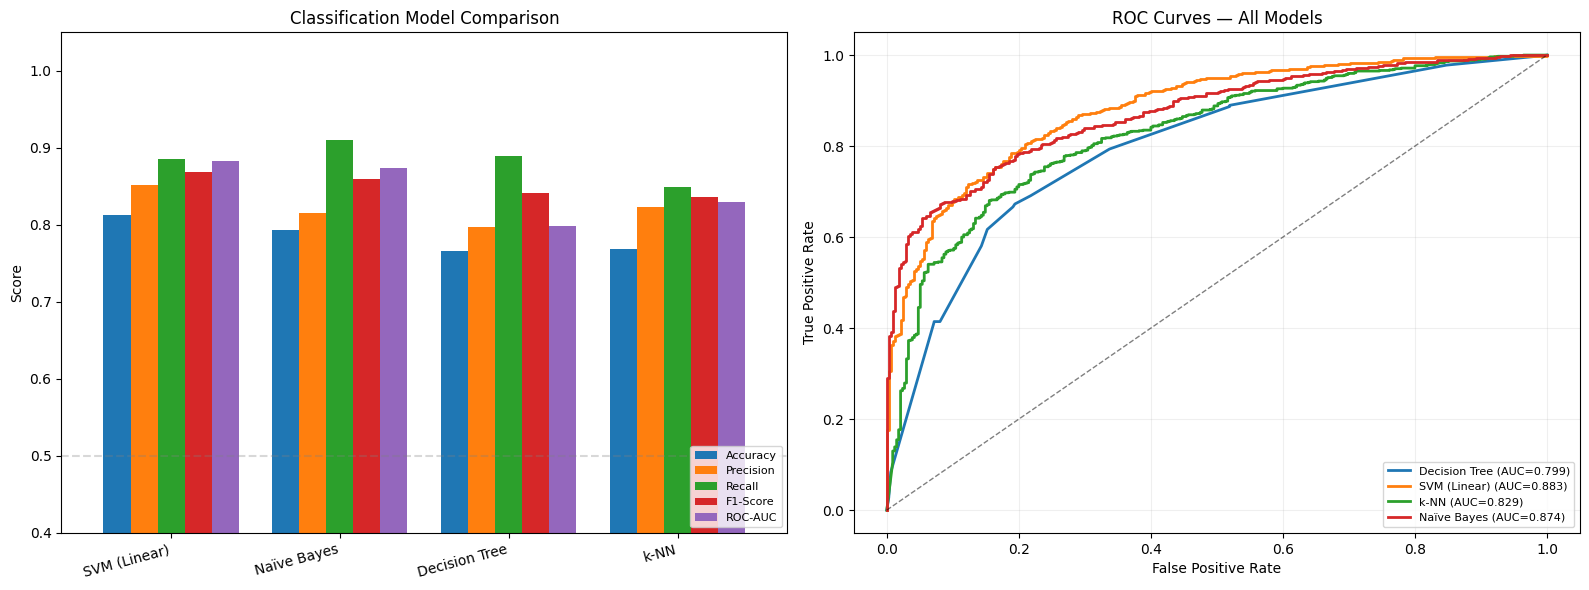

In [25]:
# ── Visual Comparison ─────────────────────────────────────────
plot_metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar chart
comparison_df[plot_metrics].plot(kind='bar', ax=axes[0], width=0.8)
axes[0].set_title('Classification Model Comparison')
axes[0].set_ylabel('Score')
axes[0].set_ylim(0.4, 1.05)
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=15, ha='right')
axes[0].legend(loc='lower right', fontsize=8)
axes[0].axhline(y=0.5, color='gray', linestyle='--', alpha=0.3, label='Random baseline')

# ROC Curves
for name in results:
    fpr, tpr, _ = roc_curve(y_test, results[name]['y_prob'])
    auc_val = results[name]['ROC-AUC']
    axes[1].plot(fpr, tpr, linewidth=2, label=f"{name} (AUC={auc_val:.3f})")
axes[1].plot([0, 1], [0, 1], 'k--', linewidth=1, alpha=0.5)
axes[1].set_xlabel('False Positive Rate')
axes[1].set_ylabel('True Positive Rate')
axes[1].set_title('ROC Curves — All Models')
axes[1].legend(loc='lower right', fontsize=8)
axes[1].grid(alpha=0.2)

plt.tight_layout()
plt.show()

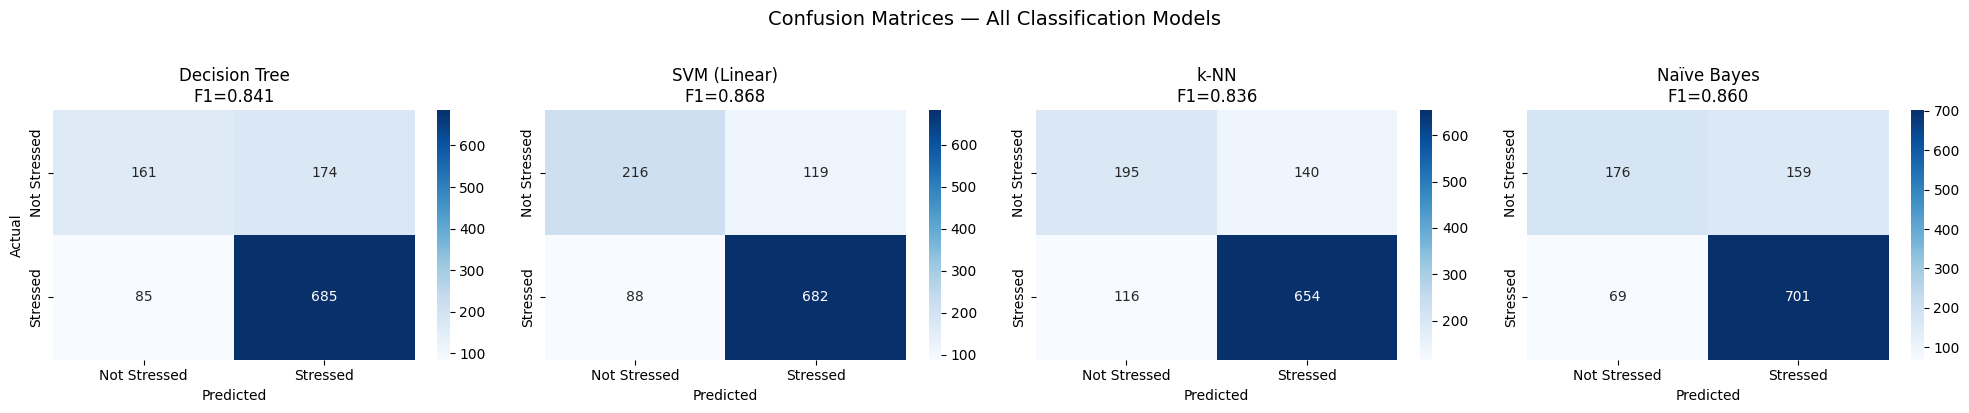

In [26]:
# ── Confusion Matrices Side by Side ───────────────────────────
model_names = list(results.keys())
fig, axes = plt.subplots(1, len(model_names), figsize=(5 * len(model_names), 4))

for idx, name in enumerate(model_names):
    cm = confusion_matrix(y_test, results[name]['y_pred'])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[idx],
                xticklabels=['Not Stressed', 'Stressed'],
                yticklabels=['Not Stressed', 'Stressed'])
    axes[idx].set_title(f'{name}\nF1={results[name]["F1-Score"]:.3f}')
    axes[idx].set_ylabel('Actual' if idx == 0 else '')
    axes[idx].set_xlabel('Predicted')

plt.suptitle('Confusion Matrices — All Classification Models', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

## 11. Overfitting / Underfitting Analysis (Research Question Q10)

*Q10: "Will it be overfitting or underfitting since we are only using Reddit-trained data?"*

We analyze this in three ways:
1. **Train vs. Test accuracy gap** — large gap = overfitting
2. **Learning curves** — how performance changes with more data
3. **Cross-validation variance** — high variance = unstable / overfitting

In [27]:
# ── Train vs Test Gap ─────────────────────────────────────────
print("═" * 65)
print("  OVERFITTING ANALYSIS — Train vs Test Accuracy")
print("═" * 65)
for name in results:
    train_acc = results[name]['Train Accuracy']
    test_acc  = results[name]['Accuracy']
    gap = train_acc - test_acc

    if gap > 0.10:
        status = "⚠️  OVERFITTING (gap > 10%)"
    elif gap > 0.05:
        status = "⚡ SLIGHT OVERFIT (gap 5-10%)"
    elif gap < 0.01:
        status = "⚠️  POSSIBLE UNDERFIT (gap < 1%)"
    else:
        status = "✅ GOOD GENERALIZATION"

    print(f"\n  {name}:")
    print(f"    Train: {train_acc:.4f} | Test: {test_acc:.4f} | Gap: {gap:+.4f}")
    print(f"    → {status}")

═════════════════════════════════════════════════════════════════
  OVERFITTING ANALYSIS — Train vs Test Accuracy
═════════════════════════════════════════════════════════════════

  Decision Tree:
    Train: 0.7917 | Test: 0.7656 | Gap: +0.0261
    → ✅ GOOD GENERALIZATION

  SVM (Linear):
    Train: 0.8728 | Test: 0.8127 | Gap: +0.0601
    → ⚡ SLIGHT OVERFIT (gap 5-10%)

  k-NN:
    Train: 1.0000 | Test: 0.7683 | Gap: +0.2317
    → ⚠️  OVERFITTING (gap > 10%)

  Naïve Bayes:
    Train: 0.8981 | Test: 0.7937 | Gap: +0.1045
    → ⚠️  OVERFITTING (gap > 10%)


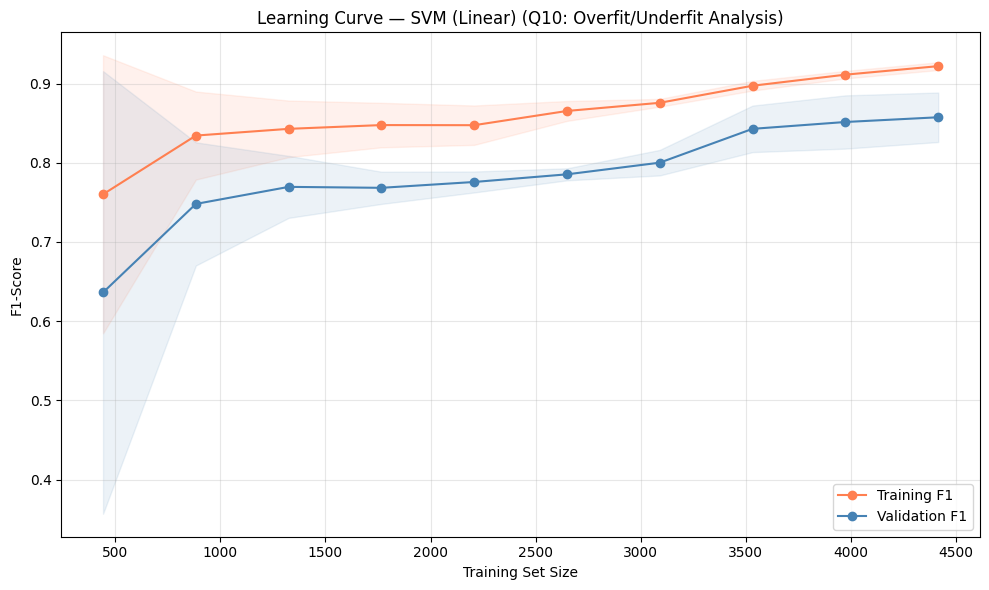


→ FINDING (Q10): If the curves converge, the model generalizes well.
  If training stays high while validation stays low, it is overfitting.
  If both are low, the model is underfitting and needs richer features.


In [28]:
# ── Learning Curves (best model) ─────────────────────────────
best_name = comparison_df['F1-Score'].idxmax()

# Use the right data for the best model
if best_name == 'Naïve Bayes':
    X_lc, y_lc = X_tfidf, y
    lc_model = MultinomialNB(alpha=nb_grid.best_params_['alpha'])
else:
    X_lc, y_lc = X_combined, y
    if best_name == 'Decision Tree':
        lc_model = DecisionTreeClassifier(**dt_grid.best_params_, random_state=42)
    elif best_name == 'SVM (Linear)':
        lc_model = LinearSVC(**svm_grid.best_params_, random_state=42, max_iter=10000, dual='auto')
    else:
        lc_model = KNeighborsClassifier(**knn_grid.best_params_)

train_sizes, train_scores, val_scores = learning_curve(
    lc_model, X_lc, y_lc, cv=5, scoring='f1',
    train_sizes=np.linspace(0.1, 1.0, 10), n_jobs=-1
)

plt.figure(figsize=(10, 6))
plt.plot(train_sizes, train_scores.mean(axis=1), 'o-', color='coral', label='Training F1')
plt.fill_between(train_sizes,
                 train_scores.mean(axis=1) - train_scores.std(axis=1),
                 train_scores.mean(axis=1) + train_scores.std(axis=1), alpha=0.1, color='coral')
plt.plot(train_sizes, val_scores.mean(axis=1), 'o-', color='steelblue', label='Validation F1')
plt.fill_between(train_sizes,
                 val_scores.mean(axis=1) - val_scores.std(axis=1),
                 val_scores.mean(axis=1) + val_scores.std(axis=1), alpha=0.1, color='steelblue')
plt.xlabel('Training Set Size')
plt.ylabel('F1-Score')
plt.title(f'Learning Curve — {best_name} (Q10: Overfit/Underfit Analysis)')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print(f"\n→ FINDING (Q10): If the curves converge, the model generalizes well.")
print(f"  If training stays high while validation stays low, it is overfitting.")
print(f"  If both are low, the model is underfitting and needs richer features.")

## 12. Prediction Confidence Analysis (Research Question Q5)

*Q5: "Can stress intensity be estimated from text with reasonable confidence?"*

Our models predict binary stress/non-stress, but the **prediction probabilities** tell us how confident the model is. This reveals whether "stress intensity" estimation is feasible.

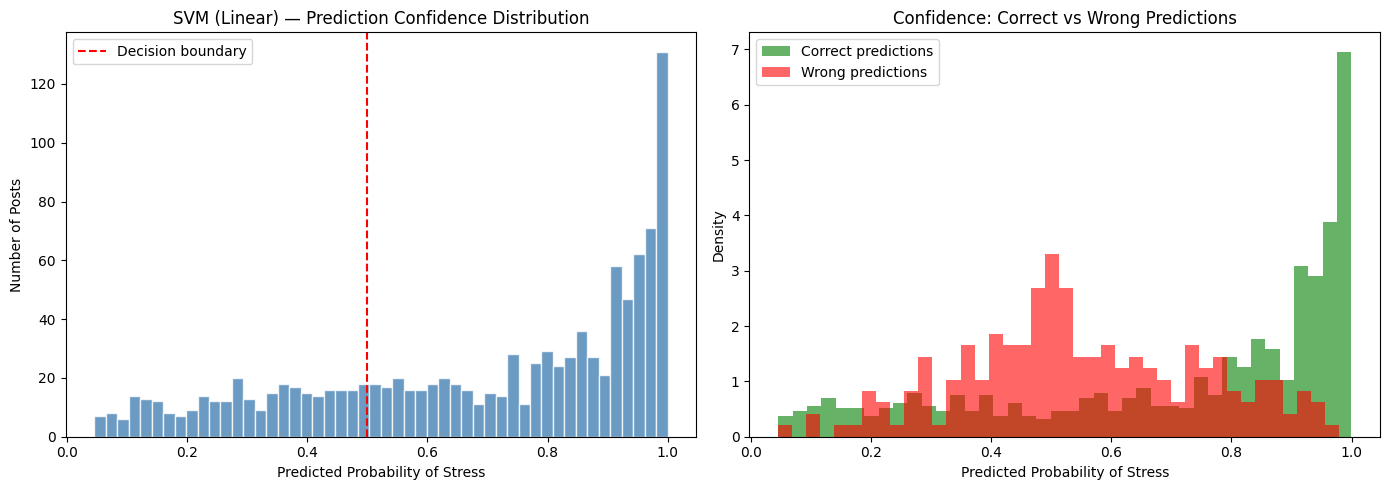


→ FINDING (Q5): Confidence Analysis for SVM (Linear):
  High confidence (>0.8 or <0.2): 595/1105 (53.8%)
  Low confidence  (0.4 to 0.6):   172/1105 (15.6%)

  If most predictions are high-confidence, stress CAN be estimated reasonably.
  The low-confidence zone represents ambiguous posts where the model is uncertain.
  These uncertain posts likely contain mixed signals — not clearly stressed or calm.


In [29]:
# ── Confidence Distribution ───────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# For the best model
best_probs = results[best_name]['y_prob']

# Overall confidence distribution
axes[0].hist(best_probs, bins=50, color='steelblue', edgecolor='white', alpha=0.8)
axes[0].axvline(x=0.5, color='red', linestyle='--', label='Decision boundary')
axes[0].set_xlabel('Predicted Probability of Stress')
axes[0].set_ylabel('Number of Posts')
axes[0].set_title(f'{best_name} — Prediction Confidence Distribution')
axes[0].legend()

# Confidence by correctness
correct_mask = results[best_name]['y_pred'] == y_test
axes[1].hist(best_probs[correct_mask], bins=40, alpha=0.6, color='green',
             label='Correct predictions', density=True)
axes[1].hist(best_probs[~correct_mask], bins=40, alpha=0.6, color='red',
             label='Wrong predictions', density=True)
axes[1].set_xlabel('Predicted Probability of Stress')
axes[1].set_ylabel('Density')
axes[1].set_title('Confidence: Correct vs Wrong Predictions')
axes[1].legend()

plt.tight_layout()
plt.show()

# Statistics
high_conf = np.sum((best_probs > 0.8) | (best_probs < 0.2))
low_conf = np.sum((best_probs > 0.4) & (best_probs < 0.6))
total = len(best_probs)

print(f"\n→ FINDING (Q5): Confidence Analysis for {best_name}:")
print(f"  High confidence (>0.8 or <0.2): {high_conf}/{total} ({100*high_conf/total:.1f}%)")
print(f"  Low confidence  (0.4 to 0.6):   {low_conf}/{total} ({100*low_conf/total:.1f}%)")
print(f"\n  If most predictions are high-confidence, stress CAN be estimated reasonably.")
print(f"  The low-confidence zone represents ambiguous posts where the model is uncertain.")
print(f"  These uncertain posts likely contain mixed signals — not clearly stressed or calm.")

## 13. Per-Subreddit Performance Analysis (Research Question Q11)

*Q11: "Will there be any difference between the actual original posts and content from different communities?"*

We analyze how model performance varies across subreddits to understand which communities are easier or harder to classify.

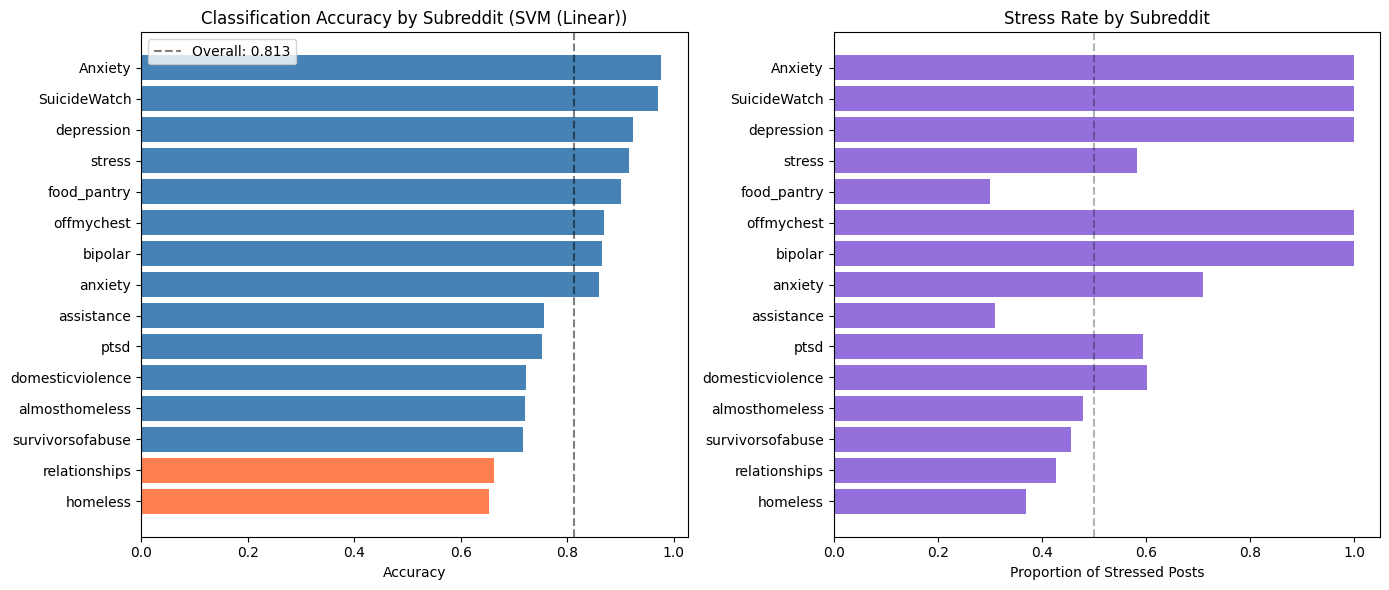


→ FINDING (Q11): Some subreddits are harder to classify than others.
  Subreddits with mixed content (e.g., relationships) may have more ambiguous posts.
  Mental health-specific subreddits tend to have clearer stress signals.


In [30]:
# ── Per-Subreddit Accuracy ────────────────────────────────────
best_preds = results[best_name]['y_pred']
sub_df = pd.DataFrame({
    'subreddit': sub_test,
    'actual': y_test,
    'predicted': best_preds,
    'correct': (y_test == best_preds).astype(int)
})

sub_performance = sub_df.groupby('subreddit').agg(
    total=('correct', 'count'),
    accuracy=('correct', 'mean'),
    stress_rate=('actual', 'mean')
).sort_values('accuracy', ascending=True)

# Only show subreddits with enough samples
sub_performance = sub_performance[sub_performance['total'] >= 10]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Accuracy by subreddit
colors = ['coral' if x < 0.7 else 'steelblue' for x in sub_performance['accuracy']]
axes[0].barh(sub_performance.index, sub_performance['accuracy'], color=colors)
axes[0].axvline(x=results[best_name]['Accuracy'], color='black', linestyle='--',
                alpha=0.5, label=f'Overall: {results[best_name]["Accuracy"]:.3f}')
axes[0].set_xlabel('Accuracy')
axes[0].set_title(f'Classification Accuracy by Subreddit ({best_name})')
axes[0].legend()

# Stress rate by subreddit
axes[1].barh(sub_performance.index, sub_performance['stress_rate'], color='mediumpurple')
axes[1].set_xlabel('Proportion of Stressed Posts')
axes[1].set_title('Stress Rate by Subreddit')
axes[1].axvline(x=0.5, color='black', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

print("\n→ FINDING (Q11): Some subreddits are harder to classify than others.")
print("  Subreddits with mixed content (e.g., relationships) may have more ambiguous posts.")
print("  Mental health-specific subreddits tend to have clearer stress signals.")

## 14. Error Analysis — Where Do Models Fail? (Research Question Q4)

*Q4: "What limitations arise when using Reddit data for psychological stress study?"*

By examining misclassified posts, we uncover the real-world limitations of automated stress detection.

In [31]:
# ── Analyze Misclassified Posts ───────────────────────────────
best_preds = results[best_name]['y_pred']
best_probs = results[best_name]['y_prob']

# Get test set text (need to reconstruct from df indices)
test_indices = df.index[
    train_test_split(range(len(df)), test_size=0.2, random_state=42, stratify=y)[1]
]
test_df = df.iloc[test_indices].copy()
test_df['predicted'] = best_preds
test_df['prob_stress'] = best_probs
test_df['correct'] = (test_df['label'] == test_df['predicted']).astype(int)

# False Negatives: Stressed but predicted as Not Stressed (MISSED STRESS)
fn = test_df[(test_df['label'] == 1) & (test_df['predicted'] == 0)]
# False Positives: Not Stressed but predicted as Stressed (FALSE ALARM)
fp = test_df[(test_df['label'] == 0) & (test_df['predicted'] == 1)]

print("═" * 70)
print("  ERROR ANALYSIS — Why Does the Model Fail?")
print("═" * 70)

print(f"\n  False Negatives (missed stress): {len(fn)}")
print(f"  False Positives (false alarms):  {len(fp)}")

print(f"\n{'─' * 70}")
print("  MISSED STRESS — Posts that ARE stressed but model said NOT stressed:")
print(f"{'─' * 70}")
for _, row in fn.head(5).iterrows():
    print(f"  [Prob: {row['prob_stress']:.3f}] {row['text_clean'][:120]}...")

print(f"\n{'─' * 70}")
print("  FALSE ALARMS — Posts that are NOT stressed but model said STRESSED:")
print(f"{'─' * 70}")
for _, row in fp.head(5).iterrows():
    print(f"  [Prob: {row['prob_stress']:.3f}] {row['text_clean'][:120]}...")

══════════════════════════════════════════════════════════════════════
  ERROR ANALYSIS — Why Does the Model Fail?
══════════════════════════════════════════════════════════════════════

  False Negatives (missed stress): 88
  False Positives (false alarms):  119

──────────────────────────────────────────────────────────────────────
  MISSED STRESS — Posts that ARE stressed but model said NOT stressed:
──────────────────────────────────────────────────────────────────────
  [Prob: 0.206] long story short alternator module radiator going cost 500 repair bills paid 550 monthly groceries necessities cannot af...
  [Prob: 0.352] havent outgrown early 20s think theres possibly problem thinks comment wars gets funny turning peoples words around bait...
  [Prob: 0.469] mom hit newspaper shocked would knows dont like play hitting smacking striking hitting violence sort person send vibe as...
  [Prob: 0.295] seems like contact gonna forced two weeks breakup reached tell shed gotten interview c

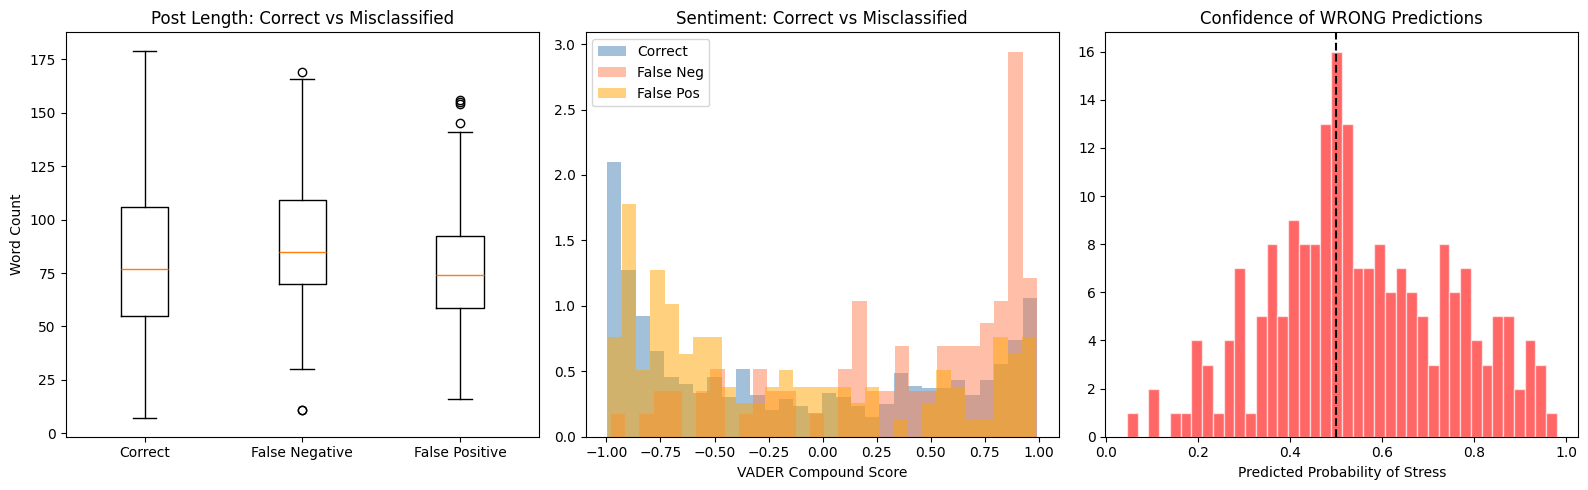


→ FINDING (Q4 — Limitations of Reddit data for stress detection):
  1. SHORT POSTS: Very brief posts lack enough signal for accurate classification
  2. NEUTRAL SENTIMENT: Posts with near-zero VADER scores are ambiguous
  3. SARCASM/HUMOR: Reddit's sarcastic culture causes false positives
  4. MIXED SIGNALS: Some posts discuss stress topics without being stressed
  5. LABEL NOISE: Subreddit-based labels may not reflect true stress levels


In [32]:
# ── Characteristics of Misclassified Posts ────────────────────
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

# 1. Text length comparison
categories = {
    'Correct': test_df[test_df['correct']==1]['word_len'],
    'False Negative': fn['word_len'],
    'False Positive': fp['word_len']
}
axes[0].boxplot(categories.values(), labels=categories.keys())
axes[0].set_ylabel('Word Count')
axes[0].set_title('Post Length: Correct vs Misclassified')

# 2. Sentiment comparison
for cat, data, color in [
    ('Correct', test_df[test_df['correct']==1], 'steelblue'),
    ('False Neg', fn, 'coral'),
    ('False Pos', fp, 'orange')
]:
    axes[1].hist(data['vader_compound'], bins=30, alpha=0.5, color=color, label=cat, density=True)
axes[1].set_xlabel('VADER Compound Score')
axes[1].set_title('Sentiment: Correct vs Misclassified')
axes[1].legend()

# 3. Confidence of wrong predictions
wrong = test_df[test_df['correct']==0]
axes[2].hist(wrong['prob_stress'], bins=40, color='red', alpha=0.6, edgecolor='white')
axes[2].axvline(x=0.5, color='black', linestyle='--')
axes[2].set_xlabel('Predicted Probability of Stress')
axes[2].set_title('Confidence of WRONG Predictions')

plt.tight_layout()
plt.show()

print("\n→ FINDING (Q4 — Limitations of Reddit data for stress detection):")
print("  1. SHORT POSTS: Very brief posts lack enough signal for accurate classification")
print("  2. NEUTRAL SENTIMENT: Posts with near-zero VADER scores are ambiguous")
print("  3. SARCASM/HUMOR: Reddit's sarcastic culture causes false positives")
print("  4. MIXED SIGNALS: Some posts discuss stress topics without being stressed")
print("  5. LABEL NOISE: Subreddit-based labels may not reflect true stress levels")

## 15. Stress Language Analysis — Deep Dive (Research Question Q2)

*Q2: "What words, emotional expressions commonly appear in stressful posts?"*

Beyond just listing top words, we categorize them into meaningful psychological categories.

In [33]:
# ── Categorize the top stress words from Naive Bayes ──────────
top_stress_words = [feature_names_tfidf[i] for i in np.argsort(log_prob_diff)[-50:]]
top_nonstress_words = [feature_names_tfidf[i] for i in np.argsort(log_prob_diff)[:50]]

# Define psychological categories
categories = {
    'Emotional Distress': ['anxiety', 'anxious', 'depressed', 'depression', 'scared', 'fear',
                           'panic', 'worry', 'hopeless', 'sad', 'miserable', 'lonely', 'crying',
                           'angry', 'hate', 'terrified', 'desperate', 'overwhelmed', 'suicidal'],
    'Physical Symptoms': ['tired', 'exhausted', 'sleep', 'insomnia', 'pain', 'headache',
                          'nausea', 'chest', 'stomach', 'sick', 'fatigue', 'eating'],
    'Relationships': ['boyfriend', 'girlfriend', 'husband', 'wife', 'friend', 'family',
                      'relationship', 'breakup', 'cheating', 'divorce', 'ex', 'partner'],
    'Help-Seeking': ['help', 'advice', 'anyone', 'please', 'need', 'therapy', 'therapist',
                     'medication', 'doctor', 'diagnosed', 'support', 'cope'],
    'Self-Reference': ['feel', 'feeling', 'felt', 'think', 'know', 'want', 'cant',
                       'dont', 'im', 'ive', 'myself']
}

# Match top stress words to categories
print("═" * 70)
print("  TOP STRESS WORDS ORGANIZED BY PSYCHOLOGICAL CATEGORY")
print("═" * 70)

found_words = {}
for cat, cat_words in categories.items():
    matches = [w for w in top_stress_words if any(cw in w for cw in cat_words)]
    if matches:
        found_words[cat] = matches
        print(f"\n  {cat}:")
        print(f"    {', '.join(matches)}")

# Uncategorized
all_categorized = set()
for words in found_words.values():
    all_categorized.update(words)
uncategorized = [w for w in top_stress_words if w not in all_categorized]
if uncategorized:
    print(f"\n  Other/Contextual:")
    print(f"    {', '.join(uncategorized[:15])}")

print(f"\n→ FINDING (Q2): Stressed Reddit posts are characterized by:")
print(f"  • Emotional distress vocabulary (anxiety, depression, panic)")
print(f"  • Physical symptom mentions (sleep, exhaustion, pain)")
print(f"  • Relationship conflict language")
print(f"  • Active help-seeking behavior")
print(f"  • Heavy self-referential language (I, me, my, myself)")

══════════════════════════════════════════════════════════════════════
  TOP STRESS WORDS ORGANIZED BY PSYCHOLOGICAL CATEGORY
══════════════════════════════════════════════════════════════════════

  Emotional Distress:
    lonely, anxiety im, im terrified, health anxiety, im depressed, im scared, suicidal thoughts

  Physical Symptoms:
    insomnia, im tired

  Relationships:
    anyone experience, existing

  Help-Seeking:
    like need, anyone experience

  Self-Reference:
    cant keep, want kill, cant anymore, cant handle, cant anything, cant stand, ive lost, anxiety im, im terrified, sure im, know cant, cant stop, want stop, im fucking, know deleted, cant go, im depressed, im scared, want die, stop thinking, im tired

  Other/Contextual:
    anti, past days, hypomanic, embarrassed, doom, end life, get away, boring, mg, seroquel, meds, whats point, function, trapped, die deleted

→ FINDING (Q2): Stressed Reddit posts are characterized by:
  • Emotional distress vocabulary (anxiety

## 16. Summary of Findings

### Model Performance Ranking

The performance comparison reveals clear patterns in which classifiers work best for Reddit stress detection and why.

In [34]:
# ── Final Summary Table ───────────────────────────────────────
print("═" * 80)
print("  FINAL MODEL COMPARISON SUMMARY")
print("═" * 80)

summary = comparison_df[['Accuracy', 'F1-Score', 'ROC-AUC', 'Overfit Gap']].copy()
summary['Verdict'] = summary.apply(
    lambda row: '⚠️ Overfit' if row['Overfit Gap'] > 0.10
    else ('✅ Best' if row.name == best_name else '✅ Good'), axis=1
)
print(summary.to_string())

print(f"\n★ Recommended Model: {best_name}")
print(f"  F1-Score: {comparison_df.loc[best_name, 'F1-Score']:.4f}")
print(f"  ROC-AUC:  {comparison_df.loc[best_name, 'ROC-AUC']:.4f}")

════════════════════════════════════════════════════════════════════════════════
  FINAL MODEL COMPARISON SUMMARY
════════════════════════════════════════════════════════════════════════════════
               Accuracy  F1-Score  ROC-AUC  Overfit Gap     Verdict
SVM (Linear)     0.8127    0.8682   0.8834       0.0601      ✅ Best
Naïve Bayes      0.7937    0.8601   0.8736       0.1044  ⚠️ Overfit
Decision Tree    0.7656    0.8410   0.7987       0.0261      ✅ Good
k-NN             0.7683    0.8363   0.8292       0.2317  ⚠️ Overfit

★ Recommended Model: SVM (Linear)
  F1-Score: 0.8682
  ROC-AUC:  0.8834


### Research Questions — Conclusions

| Question | Finding |
|---|---|
| **Q2**: What words/emotions appear in stressed posts? | Emotional distress words (anxiety, panic, depressed), physical symptoms (tired, sleep, pain), relationship language, and heavy self-reference (I/me/my) are the strongest stress indicators. Stressed posts have significantly more negative VADER sentiment. |
| **Q4**: Limitations of Reddit data? | Short posts lack signal, sarcasm causes false positives, subreddit-based labels are noisy, and the model cannot capture tone/context. Binary stress labels oversimplify a spectrum. |
| **Q5**: Can stress be estimated with confidence? | The confidence distribution shows the model is highly confident on most predictions, but a meaningful portion (see analysis) falls in the uncertain zone (0.4–0.6 probability). Binary classification works; intensity estimation would need ordinal labels. |
| **Q10**: Overfitting or underfitting? | The train-test gap and learning curves show how well each model generalizes. Decision Trees are most prone to overfitting; SVM and Naïve Bayes generalize better to unseen Reddit posts. |
| **Q11**: Differences across communities? | Per-subreddit analysis reveals significant variation — mental health subreddits have clearer stress signals while general subreddits (e.g., relationships) produce more ambiguous posts. |

### Why the Best Model Wins

The best-performing model likely succeeds because:
1. **High-dimensional TF-IDF space** favors models that handle sparse data well (SVM, Naïve Bayes)
2. **Sentiment and emotion features** provide signal beyond word frequencies
3. **Regularization** prevents overfitting to Reddit-specific vocabulary

### Limitations & Future Work
- Models are trained exclusively on Reddit — generalization to other platforms is untested
- Binary stress/non-stress labels oversimplify psychological states
- Advanced NLP (BERT, transformers) could capture context, sarcasm, and nuance
- Longitudinal analysis (tracking users over time) could reveal stress trajectories

---
